## 1. Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from module_function import KMeansClustering,ClusteringVisualizer

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
df = pd.read_csv('dataset/Customers_CLEANING.csv')
df.head(3)

,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,Male,19,15000,39,Healthcare,1,4
1,Male,21,35000,81,Engineer,3,3
2,Female,20,86000,6,Engineer,1,1


## 2. Feature Scaling

In [3]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy="mean")),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas")
X_cleaned = preprocessor.fit_transform(df)

## 3. The Analysis K Selection in Kmean++

In [4]:
cluster_model = KMeansClustering(range_max=12, df_raw=df)
cluster_model.fit_model(X_cleaned)
cluster_model.compute_scores_dataframe()

[INFO] Model berhasil dilatih untuk semua rentang k.


,n_clusters(k),Inertia (WCSS),Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Composite_Score
0,2,11055.762283,0.117022,275.588027,2.639440,0.666667
1,3,9968.173858,0.112580,261.421157,2.274691,0.642915
2,4,9255.518028,0.109380,238.706772,2.076815,0.561885
3,5,8714.681199,0.110463,220.920324,2.041491,0.548543
4,6,8250.518765,0.113042,208.965042,1.900240,0.633782
5,7,7895.308487,0.109444,196.787202,1.857561,0.515928
6,8,7581.685861,0.104527,187.305740,1.898259,0.339555
7,9,7239.591495,0.113874,183.281224,1.765451,0.626963
8,10,7111.578833,0.105731,169.735863,1.862374,0.330344
9,11,6793.117882,0.107483,169.144176,1.843322,0.382489


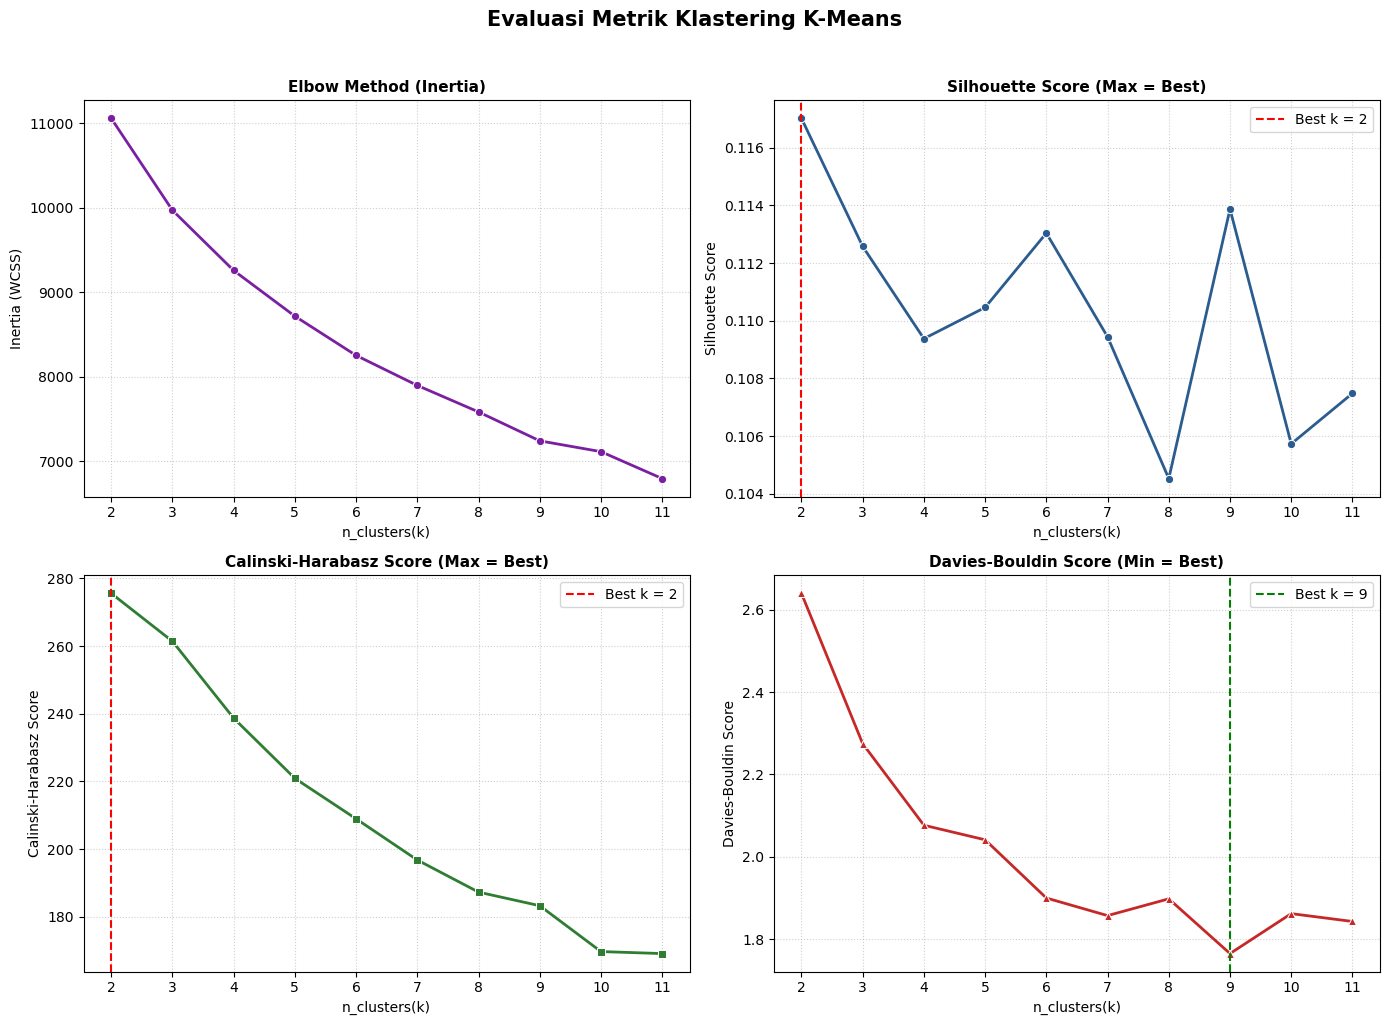

In [5]:
visualizer = ClusteringVisualizer(cluster_model)
visualizer.plot_evaluation_metrics()

[INFO] Model optimal dipilih dengan jumlah cluster (k) = 2


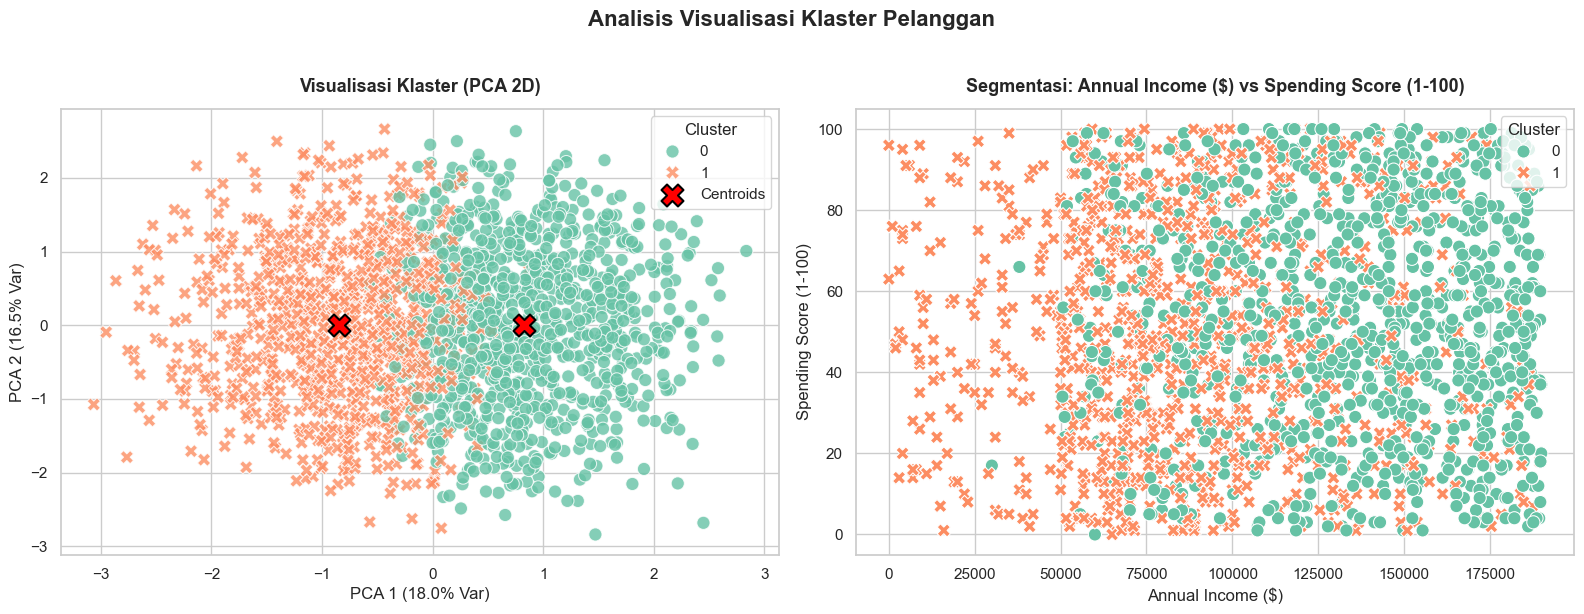

In [6]:
best_kmeans, df_clustered = cluster_model.fit_best_model(X_cleaned)
visualizer.plot_cluster_results(
    X_cleaned=X_cleaned, 
    best_kmeans=best_kmeans, 
    feature_x='Annual Income ($)',   # Sesuaikan dengan nama kolom dataset Anda
    feature_y='Spending Score (1-100)' # Sesuaikan dengan nama kolom dataset Anda
)

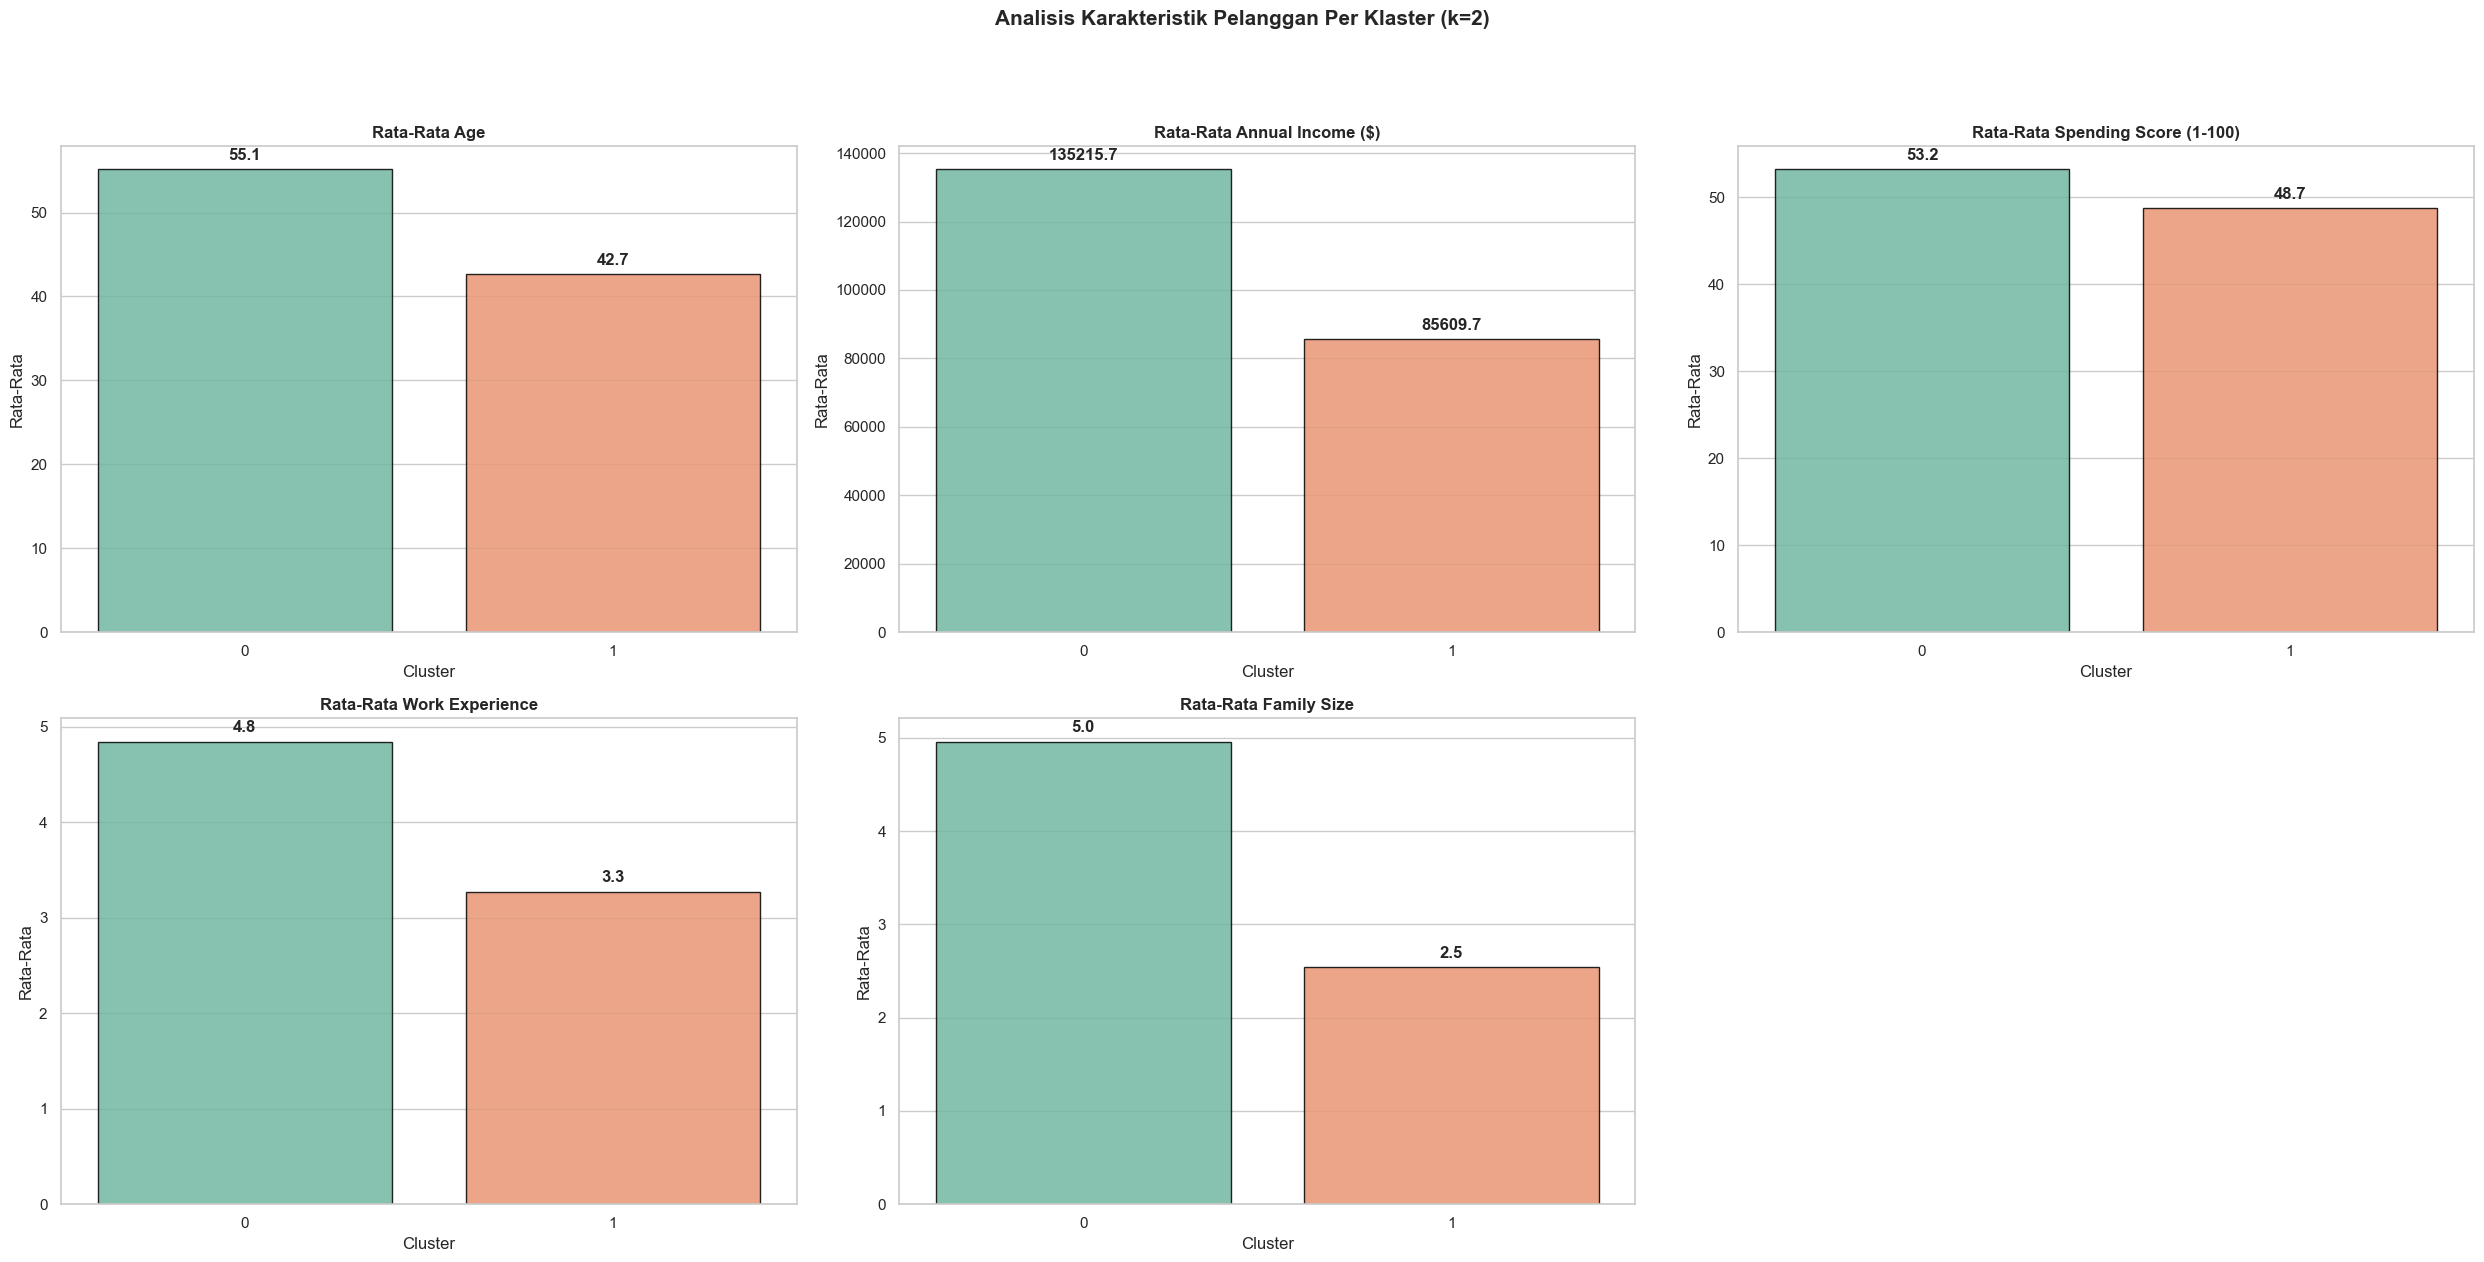

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
visualizer.plot_cluster_characteristic(num_cols)